# **1-Import of Main libraries**

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,BatchNormalization,ReLU,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB3,EfficientNetB5,DenseNet121 , EfficientNetV2S
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.layers import TextVectorization
import pickle
import pandas as pd
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout,
    LayerNormalization, Concatenate, Reshape, Attention,GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Reshape,LayerNormalization
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
IMG_SIZE = 224
Q_MAX_LEN = 32
A_MAX_LEN = 12
BATCH_SIZE=64

# **2-Preparing Pathes For Training and Preprocessing**

In [14]:
train_df = pd.read_csv("/kaggle/input/datasets/b0o0da/visual-qa-dataset/train.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/b0o0da/visual-qa-dataset/val.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/b0o0da/visual-qa-dataset/test.csv")



with open("/kaggle/input/datasets/b0o0da/visual-qa-dataset/question_vocab.pkl", "rb") as f:
    Q_vocab = pickle.load(f)

Q_vectorizer = TextVectorization(
    max_tokens=len(Q_vocab),
    output_mode="int",
    output_sequence_length=Q_MAX_LEN
)

Q_vectorizer.set_vocabulary(Q_vocab)


with open("/kaggle/input/datasets/b0o0da/visual-qa-dataset/answer_vocab.pkl", "rb") as f:
    A_vocab = pickle.load(f)

A_vectorizer = TextVectorization(
    max_tokens=len(A_vocab),
    output_mode="int",
    output_sequence_length=A_MAX_LEN
)

A_vectorizer.set_vocabulary(A_vocab)

In [15]:
import os
import pandas as pd

BASE_DIR = "/kaggle/input/datasets/b0o0da/visual-qa-dataset/dataset_images/dataset_images"

def fix_image_path(p):
    p = str(p).strip()
    filename = os.path.basename(p)
    return os.path.join(BASE_DIR, filename)

train_df["image_path"] = train_df["image_path"].apply(fix_image_path)
val_df["image_path"] = val_df["image_path"].apply(fix_image_path)
test_df["image_path"] = test_df["image_path"].apply(fix_image_path)


In [16]:
def preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [17]:
def make_dataset(df, Q_vectorizer, A_vectorizer, batch_size=BATCH_SIZE, shuffle=True):
    image_paths = df["image_path"].values
    questions   = df["question"].values
    answers     = df["answer"].values

    ds = tf.data.Dataset.from_tensor_slices((image_paths, questions, answers))

    if shuffle:
        ds = ds.shuffle(200, reshuffle_each_iteration=True)

    def process(path, question, answer):
        img   = preprocess_image(path)
        q_seq = Q_vectorizer(question)
        q_seq = q_seq[:-1]
        a_seq          = A_vectorizer(answer)
        decoder_input  = a_seq[:-1]
        target         = a_seq[1:]

        sample_weight  = tf.cast(target != 0, tf.float32)

        return (img, q_seq, decoder_input), target, sample_weight

    ds = ds.map(process, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, Q_vectorizer, A_vectorizer, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(val_df,   Q_vectorizer, A_vectorizer, batch_size=BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(test_df,  Q_vectorizer, A_vectorizer, batch_size=BATCH_SIZE, shuffle=False)

# **3-Build EfficientNetB5 ENCODER**

In [18]:
base_cnn = EfficientNetB5(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling=None
)

base_cnn.trainable = False

image_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

x_img = data_augmentation(image_input)
x_img = base_cnn(x_img)

x_img = Reshape((-1, x_img.shape[-1]))(x_img)

x_img = Dense(256, activation="relu")(x_img)
x_img = LayerNormalization()(x_img)
x_img = Dropout(0.2)(x_img)

cnn_model = Model(inputs=image_input, outputs=x_img, name="cnn_branch")
cnn_model.summary()

Model: "cnn_branch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb5 (Functional)     │ (None, 7, 7, 2048)     │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 49, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 49, 256)        │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 49, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 49, 256)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,038,583 (110.77 MB)

 Trainable params: 525,056 (2.00 MB)

 Non-trainable params: 28,513,527 (108.77 MB)

# **4-Build RNN LSTM Decoder**

In [19]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout,
    LayerNormalization, Concatenate, Reshape,
    GlobalAveragePooling1D, RepeatVector
)

Q_VOCAB_SIZE = len(Q_vectorizer.get_vocabulary())
A_VOCAB_SIZE = len(A_vectorizer.get_vocabulary())

EMB_DIM = 128
LSTM_UNITS = 128

# =========================
# INPUTS
# =========================
image_input    = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
question_input = Input(shape=(Q_MAX_LEN - 1,), name="question_input")
answer_input   = Input(shape=(A_MAX_LEN - 1,), name="answer_input")

# =========================
# IMAGE ENCODER
# =========================
img_feat = cnn_model(image_input)
img_feat = Reshape((-1, img_feat.shape[-1]))(img_feat)
img_feat = Dense(EMB_DIM, activation="relu")(img_feat)
img_feat = Dropout(0.2)(img_feat)

# =========================
# QUESTION ENCODER
# =========================
q = Embedding(Q_VOCAB_SIZE, EMB_DIM, mask_zero=False)(question_input)
q = LSTM(LSTM_UNITS, return_sequences=False)(q)
q = Dense(EMB_DIM, activation="relu")(q)

# دمج الصورة والسؤال
q_expanded = RepeatVector(49)(q)
fusion = Concatenate()([img_feat, q_expanded])
fusion = Dense(EMB_DIM, activation="relu")(fusion)
fusion = GlobalAveragePooling1D()(fusion)
context = RepeatVector(A_MAX_LEN - 1)(fusion)

# =========================
# ANSWER DECODER
# =========================
a = Embedding(A_VOCAB_SIZE, EMB_DIM, mask_zero=False)(answer_input)
a = LSTM(LSTM_UNITS, return_sequences=True)(a)

# دمج الـ context مع الـ answer
x = Concatenate()([a, context])
x = Dense(EMB_DIM, activation="relu")(x)
x = Dropout(0.2)(x)

# =========================
# OUTPUT
# =========================
output = Dense(A_VOCAB_SIZE, activation="softmax")(x)

# =========================
# MODEL
# =========================
vqa_model = Model(
    inputs=[image_input, question_input, answer_input],
    outputs=output,
    name="vqa_seq2seq_light"
)

vqa_model.summary()

Model: "vqa_seq2seq_light"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_input      │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch          │ (None, 49, 256)   │ 29,038,583 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 31, 128)   │     27,776 │ question_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 49, 256)   │          0 │ cnn_branch[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 128)       │    131,584 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 49, 128)   │     32,896 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     16,512 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 49, 128)   │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_2     │ (None, 49, 128)   │          0 │ dense_8[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 49, 256)   │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ repeat_vector_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_input        │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 49, 128)   │     32,896 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 11, 128)   │    384,000 │ answer_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ dense_9[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 11, 128)   │    131,584 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_3     │ (None, 11, 128)   │          0 │ global_average_p… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 11, 256)   │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ repeat_vector_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 11, 128)   │     32,896 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 30,215,727 (115.26 MB)

 Trainable params: 1,702,200 (6.49 MB)

 Non-trainable params: 28,513,527 (108.77 MB)

# **5-Build Custom Accuracy-Loss-BLEU Functions**

In [20]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="none"
)

def masked_loss(y_true, y_pred):
    # compute per-token loss
    loss = loss_object(y_true, y_pred)

    # mask padding tokens (0 = PAD)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)

    loss = loss * mask

    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    # predicted word id
    y_pred_ids = tf.argmax(y_pred, axis=-1)

    # ensure same dtype
    y_true = tf.cast(y_true, tf.int32)
    y_pred_ids = tf.cast(y_pred_ids, tf.int32)

    # check matches
    matches = tf.cast(tf.equal(y_true, y_pred_ids), tf.float32)

    # mask padding
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)

    matches = matches * mask

    return tf.reduce_sum(matches) / tf.reduce_sum(mask)

smooth = SmoothingFunction().method1

def ids_to_words(ids, vocab):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx == 0:
            continue
        if idx >= len(vocab):
            continue
        word = vocab[idx]
        if word == "end":
            break
        if word != "start":
            words.append(word)
    return words

class BleuCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset, A_vocab, num_batches=5):
        super().__init__()
        self.val_dataset = val_dataset
        self.vocab = A_vocab
        self.num_batches = num_batches

    def on_epoch_end(self, epoch, logs=None):
        bleu_scores = []

        for batch in self.val_dataset.take(self.num_batches):
            if isinstance(batch, (tuple, list)):
                if len(batch) == 2:
                    inputs, y_true = batch
                elif len(batch) == 3:
                    inputs, y_true, _ = batch
                else:
                    continue
            else:
                continue

            y_pred = self.model.predict(inputs, verbose=0)
            y_pred_ids = np.argmax(y_pred, axis=-1)
            y_true = y_true.numpy()

            for true_seq, pred_seq in zip(y_true, y_pred_ids):
                ref = ids_to_words(true_seq, self.vocab)
                hyp = ids_to_words(pred_seq, self.vocab)

                if ref and hyp:
                    bleu_scores.append(
                        sentence_bleu([ref], hyp, smoothing_function=smooth)
                    )

        mean_bleu = np.mean(bleu_scores) if bleu_scores else 0.0
        logs = logs or {}
        logs["val_BLEU"] = mean_bleu
        print(f"\nval_BLEU: {mean_bleu:.4f}")

# **6-Compiling And Callbacks**

In [21]:
vqa_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=masked_loss,
    metrics=[masked_accuracy]
)

In [22]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_vqa_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

# **7-Training Model**

In [23]:
train_imgs = set(train_df["image_path"].values)
val_imgs   = set(val_df["image_path"].values)
overlap    = train_imgs & val_imgs

print(f"Overlap in images: {len(overlap)}")

train_q = set(train_df["question"].values)
val_q   = set(val_df["question"].values)

train_a = set(train_df["answer"].values)
val_a = set(val_df["answer"].values)

print(f"Overlap in questions: {len(train_q & val_q)}")
print(f"Overlap in answer: {len(train_a & val_a)}")

Overlap in images: 0
Overlap in questions: 71
Overlap in answer: 1640


In [25]:
vocab = A_vectorizer.get_vocabulary()

bleu_callback = BleuCallback(val_ds, vocab)

base_cnn.trainable = True

for layer in base_cnn.layers[:-20]:
    layer.trainable = False

history = vqa_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_list + [bleu_callback],
    verbose=1
)

Epoch 1/10


E0000 00:00:1778555005.228971    1145 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/vqa_seq2seq_light_1/cnn_branch_1/efficientnetb5_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778555009.515222    1223 cuda_dnn.cc:529] Loaded cuDNN version 91002


1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - loss: 2.4450 - masked_accuracy: 0.3719
Epoch 1: val_loss improved from inf to 3.37746, saving model to best_vqa_model.keras

val_BLEU: 0.0234
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 777s 617ms/step - loss: 2.4448 - masked_accuracy: 0.3719 - val_loss: 3.3775 - val_masked_accuracy: 0.3449 - learning_rate: 0.0010 - val_BLEU: 0.0234
Epoch 2/10
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - loss: 1.6839 - masked_accuracy: 0.5110
Epoch 2: val_loss improved from 3.37746 to 2.86175, saving model to best_vqa_model.keras

val_BLEU: 0.0372
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 737s 613ms/step - loss: 1.6839 - masked_accuracy: 0.5110 - val_loss: 2.8618 - val_masked_accuracy: 0.3907 - learning_rate: 0.0010 - val_BLEU: 0.0372
Epoch 3/10
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - loss: 1.4769 - masked_accuracy: 0.5389
Epoch 3: val_loss improved from 2.86175 to 2.64065, saving model to best_vqa_model.keras

val_BLEU: 0.0822
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 724s 602ms/s

# **8-Fine Tuning Step**

In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_Model_caption_ft.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

base_cnn.trainable = True

for layer in base_cnn.layers[:-50]:
    layer.trainable = False

vqa_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=masked_loss,
    metrics=[masked_accuracy]
)

history_ft = vqa_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_list + [bleu_callback],
    verbose=1
)

Epoch 1/8


E0000 00:00:1778562277.176752    1145 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/vqa_seq2seq_light_1/cnn_branch_1/efficientnetb5_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - loss: 1.9167 - masked_accuracy: 0.5093
Epoch 1: val_loss improved from inf to 2.04060, saving model to best_Model_caption_ft.keras

val_BLEU: 0.1307
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 773s 615ms/step - loss: 1.9166 - masked_accuracy: 0.5093 - val_loss: 2.0406 - val_masked_accuracy: 0.5217 - learning_rate: 1.0000e-05 - val_BLEU: 0.1307
Epoch 2/8
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - loss: 1.6125 - masked_accuracy: 0.5294
Epoch 2: val_loss improved from 2.04060 to 1.92996, saving model to best_Model_caption_ft.keras

val_BLEU: 0.1292
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 722s 600ms/step - loss: 1.6126 - masked_accuracy: 0.5294 - val_loss: 1.9300 - val_masked_accuracy: 0.5277 - learning_rate: 1.0000e-05 - val_BLEU: 0.1292
Epoch 3/8
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - loss: 1.4870 - masked_accuracy: 0.5430
Epoch 3: val_loss improved from 1.92996 to 1.86792, saving model to best_Model_caption_ft.keras

val_BLEU: 0.1341
1202/1202 ━━━━━━

In [29]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_Model_caption_ft_2.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

base_cnn.trainable = True

for layer in base_cnn.layers[:-70]:
    layer.trainable = False

vqa_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=masked_loss,
    metrics=[masked_accuracy]
)

history_ft = vqa_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=callbacks_list + [bleu_callback],
    verbose=1
)

Epoch 1/6


E0000 00:00:1778568392.655695    1145 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/vqa_seq2seq_light_1/cnn_branch_1/efficientnetb5_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - loss: 1.2597 - masked_accuracy: 0.5737
Epoch 1: val_loss improved from inf to 1.76263, saving model to best_Model_caption_ft_2.keras

val_BLEU: 0.1466
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 767s 614ms/step - loss: 1.2597 - masked_accuracy: 0.5737 - val_loss: 1.7626 - val_masked_accuracy: 0.5445 - learning_rate: 1.0000e-05 - val_BLEU: 0.1466
Epoch 2/6
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - loss: 1.2435 - masked_accuracy: 0.5769
Epoch 2: val_loss improved from 1.76263 to 1.75441, saving model to best_Model_caption_ft_2.keras

val_BLEU: 0.1477
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 723s 601ms/step - loss: 1.2436 - masked_accuracy: 0.5769 - val_loss: 1.7544 - val_masked_accuracy: 0.5455 - learning_rate: 1.0000e-05 - val_BLEU: 0.1477
Epoch 3/6
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - loss: 1.2290 - masked_accuracy: 0.5785
Epoch 3: val_loss improved from 1.75441 to 1.74688, saving model to best_Model_caption_ft_2.keras

val_BLEU: 0.1461
1202/1202 

# **9-Quick Evaluation for Model**

In [30]:
vqa_model = tf.keras.models.load_model(
    r"/kaggle/working/best_Model_caption_ft_2.keras",
    custom_objects={"masked_loss": masked_loss,
                    "masked_accuracy": masked_accuracy}
)

results = vqa_model.evaluate(test_ds, verbose=1)

print("\nValidation Loss     :", results[0])
print("Validation Accuracy :", results[1])

151/151 ━━━━━━━━━━━━━━━━━━━━ 85s 492ms/step - loss: 1.5816 - masked_accuracy: 0.5399

Validation Loss     : 1.7975988388061523
Validation Accuracy : 0.5441883206367493


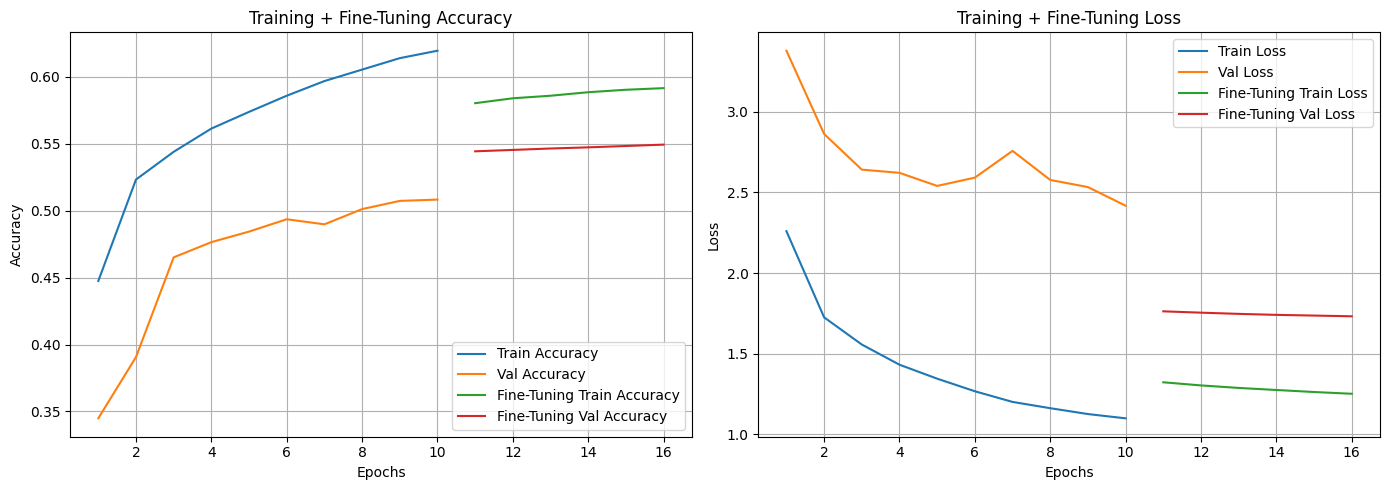

In [31]:
history_ft.history['masked_accuracy']
history_ft.history['val_masked_accuracy']


train_acc = history.history['masked_accuracy']
val_acc = history.history['val_masked_accuracy']

ft_train_acc = history_ft.history['masked_accuracy']
ft_val_acc = history_ft.history['val_masked_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

ft_train_loss = history_ft.history['loss']
ft_val_loss = history_ft.history['val_loss']


epochs_train_val = range(1, len(train_acc)+1)
epochs_full = range(len(train_acc)+1, len(train_acc)+len(ft_train_acc)+1)

plt.figure(figsize=(14,5))


plt.subplot(1,2,1)
plt.plot(epochs_train_val, train_acc, label='Train Accuracy')
plt.plot(epochs_train_val, val_acc, label='Val Accuracy')
plt.plot(epochs_full, ft_train_acc, label='Fine-Tuning Train Accuracy')
plt.plot(epochs_full, ft_val_acc, label='Fine-Tuning Val Accuracy')
plt.title('Training + Fine-Tuning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(epochs_train_val, train_loss, label='Train Loss')
plt.plot(epochs_train_val, val_loss, label='Val Loss')
plt.plot(epochs_full, ft_train_loss, label='Fine-Tuning Train Loss')
plt.plot(epochs_full, ft_val_loss, label='Fine-Tuning Val Loss')
plt.title('Training + Fine-Tuning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()